# Geostationary Lightning Mapper (GLM) Climatology in Western Colorado

An examination of convective behavior in Western Colorado using data from the GLM.

The GLM is an instrument on NOAA's Geostationary Operational Environmental Satellite (GOES) that measures lightning flashes ([Rudlosky et al. 2019, *GRL*](https://doi.org/10.1029/2018GL081052)). Lightning flashes are derived using the Lightning Cluster Filter Algorithm (LCFA). This algorithm clusters data as follows:

- Event: A single pixel observed by GLM to contain lightning
- Group: Adjacent events at the same time that are clustered together
- Flashes: A combination of one or more groups at different times

The LCFA can be displayed graphically as follows ([image source](https://www.goes-r.gov/products/docs/PUG-L2+-vol5.pdf)):  
  
<img src="./LCFA_diagram.png" alt="LCFA algorithm" width="500">

For this project, we will focus only on flashes in order to reduce the overall data volume.

## Study Domain

The study domain is highlighted in the red box below and includes the mountains of Western Colorado

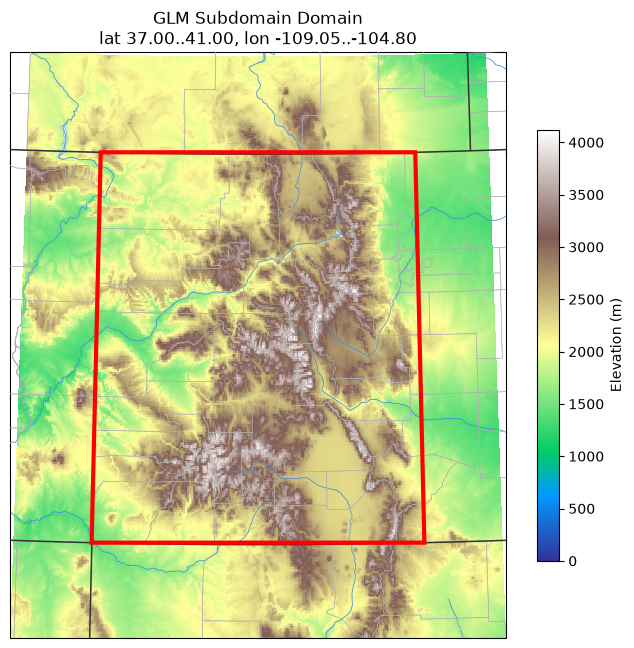

In [1]:
# Plot study domain

%run plot_glm_subdomain.py --no_save

## Acquiring GOES GLM Data

Many GOES products are available on Amazon AWS here: https://registry.opendata.aws/noaa-goes/. Datasets are broken down based on satellite. We'll only focus on GOES-East, which is either GOES-16 or GOES-19 depending on the time. Within the S3 buckets on Amazon AWS, postprocessed GLM data is stored in the `GLM-L2-LCFA` directory.

### Downloading GOES GLM Data

Two utilities are provided that handle the downloading of GLM data. Some details for these utilities are provided below. For additional information, see the docstring for each program.

#### 1. download_glm_frontrange.py

**Usage:** `python download_glm_frontrange.py --start YYYY-MM-DD --end YYYY-MM-DD`

**Description**: This script downloads all GLM data files between the dates specified using the command-line arguments. After each individual file is downloaded, it is postprocessed by:

- Only keeping flashes in the Front Range domain (see above)
- Only keeping flashes with `flash_quality_flag == 0`
- Deleting all lightning event and group information

This postprocessing significantly reduces the overall data size and may even result in some files being entirely discarded if no flashes are found within the Front Range domain. At the end of each day, all GLM files are concatenated into a single, daily netCDF file named `DDD.nc` and all intermediate files are deleted.

#### 2. combine_glm_year.py

**Usage:** `python combine_glm_year.py YYYY`

**Description**: Combine all daily netCDF files from a single year into a single netCDF file named `YYYY.nc` for easier use.